# llama3.3:70b + pdfplumber — Current Results

One model, one extractor, under the current pipeline:


## Setup

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old,
    micro_prf1, compute_f1_rows, confusion_matrix_df,
)
from dmpbridge.evaluation.annotation_rules import convert_tag_to_final, load_method_new
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

MODEL   = "llama3.3:70b"
TAG     = "llama3.3-70b_pdfplumber_whole_doc"
EXCLUDE = []          # all 10 samples
BLUE, GREEN = "#1d4ed8", "#059669"

df_a, conf_a, err_a = load_method_old(TAG, exclude=EXCLUDE)
if df_a is None:
    raise FileNotFoundError(
        f"No output for {TAG}. Run:\n"
        f"  dmpbridge-wholedoc --model {MODEL} --extractor pdfplumber --start 1 --end 10")
convert_tag_to_final(TAG)
df_b, conf_b, err_b = load_method_new(TAG, exclude=EXCLUDE)

print(f"{MODEL} + pdfplumber — {len(df_a)} samples loaded")

llama3.3:70b + pdfplumber — 10 samples loaded


## 1 — Headline scores

**Path A** scores the structured output against the original annotation.
**Path B** applies the Rules.xlsx conversion first, then scores against the newer annotation.

Precision falls when the model invents content; recall falls when it misses real content.
F1 balances both.

In [2]:
rows = []
for path, conf in (("A", conf_a), ("B", conf_b)):
    m = micro_prf1(conf)
    rows.append({"path": path, "precision": m["precision"] * 100,
                 "recall": m["recall"] * 100, "f1": m["f1"] * 100,
                 "TP": m["tp"], "FP": m["fp"], "FN": m["fn"]})
summary = pd.DataFrame(rows).set_index("path")

print(f"{MODEL} + pdfplumber   ·   all 10 samples\n")
print(f"{'path':<8}{'Precision':>11}{'Recall':>9}{'F1':>9}{'TP':>7}{'FP':>6}{'FN':>6}")
print('-' * 56)
for p, r in summary.iterrows():
    print(f"{'Path ' + p:<8}{r['precision']:>10.1f}%{r['recall']:>8.1f}%{r['f1']:>8.1f}%"
          f"{r['TP']:>7.0f}{r['FP']:>6.0f}{r['FN']:>6.0f}")
print()
print("TP = correct    FP = produced but not in the reference    FN = in the reference but missed")

llama3.3:70b + pdfplumber   ·   all 10 samples

path      Precision   Recall       F1     TP    FP    FN
--------------------------------------------------------
Path A        72.1%    80.3%    76.0%    106    41    26
Path B        72.0%    80.6%    76.1%    108    42    26

TP = correct    FP = produced but not in the reference    FN = in the reference but missed


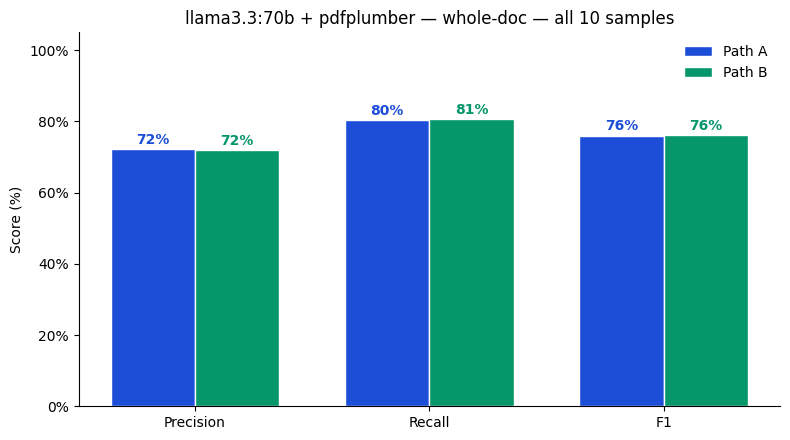

In [3]:
metrics = ["precision", "recall", "f1"]
labels  = ["Precision", "Recall", "F1"]
w = 0.36

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (path, color) in enumerate(zip(("A", "B"), (BLUE, GREEN))):
    vals = [summary.loc[path, m] for m in metrics]
    bars = ax.bar([x + (i - 0.5) * w for x in range(len(metrics))], vals, width=w,
                  label=f"Path {path}", color=color, edgecolor="white")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5, f"{v:.0f}%",
                ha="center", fontsize=10, fontweight="bold", color=color)
ax.set_xticks(range(len(metrics)))
ax.set_xticklabels(labels)
ax.set_ylim(0, 105)
ax.set_ylabel("Score (%)")
ax.set_title(f"{MODEL} + pdfplumber — whole-doc — all 10 samples")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

## 2 — Per-label F1

Which of the five labels the model handles well. `gold items` is how many exist in the
reference data — a small count means the score is unstable.

label                       Path A    Path B   gold items
---------------------------------------------------------
title                        90.0%     90.0%           10
section.title                79.1%     79.1%           43
section.description          53.3%     53.3%            8
question.text                47.4%     51.2%           18
answer.text                  83.5%     83.5%           55


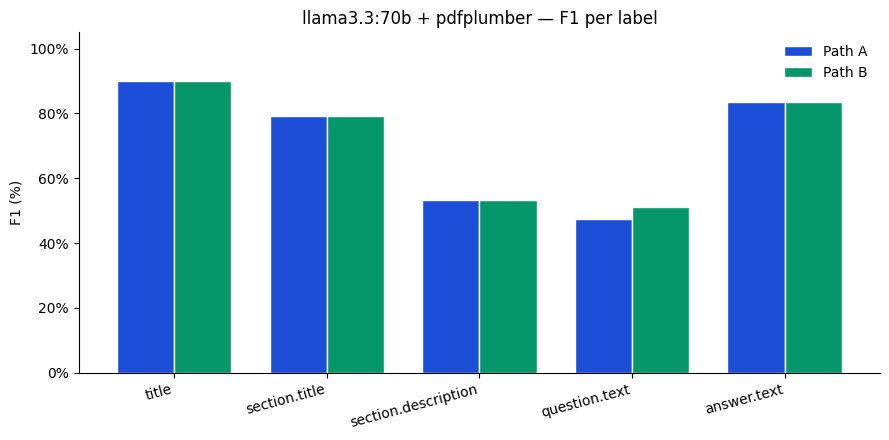

In [4]:
fa = compute_f1_rows(conf_a).set_index("label")
fb = compute_f1_rows(conf_b).set_index("label")
per_label = pd.DataFrame({"Path A": fa["f1"] * 100, "Path B": fb["f1"] * 100})

print(f"{'label':<24}{'Path A':>10}{'Path B':>10}{'gold items':>13}")
print('-' * 57)
for lab, row in per_label.iterrows():
    print(f"{lab:<24}{row['Path A']:>9.1f}%{row['Path B']:>9.1f}%{fb.loc[lab, 'support']:>13}")

ax = per_label.plot(kind="bar", figsize=(9, 4.5), width=0.75,
                    color=[BLUE, GREEN], edgecolor="white")
ax.set_ylabel("F1 (%)")
ax.set_xlabel("")
ax.set_ylim(0, 105)
ax.set_title(f"{MODEL} + pdfplumber — F1 per label")
ax.legend(frameon=False)
plt.xticks(rotation=15, ha="right")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

## 3 — Per-sample accuracy

Which documents the model handles and which it struggles with.

sample     correct  total   accuracy
------------------------------------
1               26     28      92.9%
2               14     25      56.0%
3               12     14      85.7%
4                3      3     100.0%
5                9     13      69.2%
6                6     11      54.5%
7                3      3     100.0%
8               13     13     100.0%
9                9     11      81.8%
10              13     13     100.0%
------------------------------------
TOTAL          108    134      80.6%


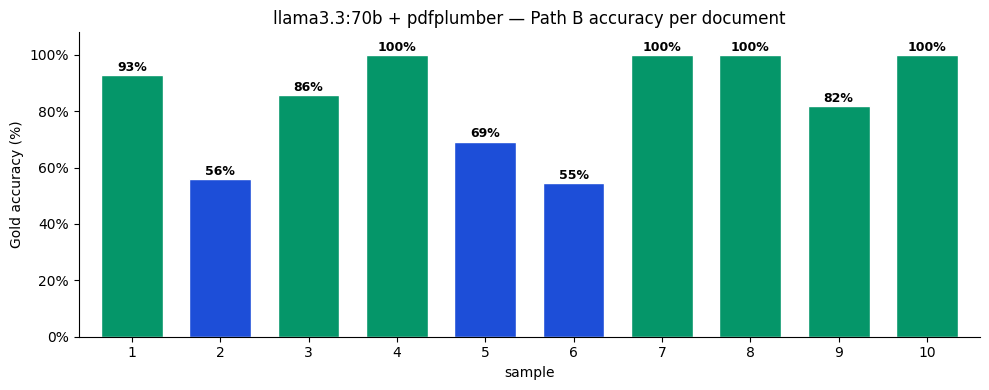

In [5]:
ps = df_b.set_index("sample").copy()
ps.index = [s.replace("sample", "") for s in ps.index]
ps = ps.loc[sorted(ps.index, key=int)]

print(f"{'sample':<9}{'correct':>9}{'total':>7}{'accuracy':>11}")
print('-' * 36)
for s, r in ps.iterrows():
    print(f"{s:<9}{r['correct']:>9.0f}{r['total']:>7.0f}{r['accuracy'] * 100:>10.1f}%")
print('-' * 36)
print(f"{'TOTAL':<9}{ps['correct'].sum():>9.0f}{ps['total'].sum():>7.0f}"
      f"{ps['correct'].sum() / ps['total'].sum() * 100:>10.1f}%")

colors = ["#dc2626" if v < 0.5 else GREEN if v >= 0.8 else BLUE for v in ps["accuracy"]]
ax = (ps["accuracy"] * 100).plot(kind="bar", figsize=(10, 4), color=colors,
                                 width=0.7, edgecolor="white")
for i, v in enumerate(ps["accuracy"] * 100):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Gold accuracy (%)")
ax.set_xlabel("sample")
ax.set_ylim(0, 108)
ax.set_title(f"{MODEL} + pdfplumber — Path B accuracy per document")
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
sns.despine()
plt.tight_layout()
plt.show()

## 4 — Confusion matrix

Rows are the true label, columns what the model predicted. The diagonal is correct;
`missed` counts reference items the model produced nothing for.

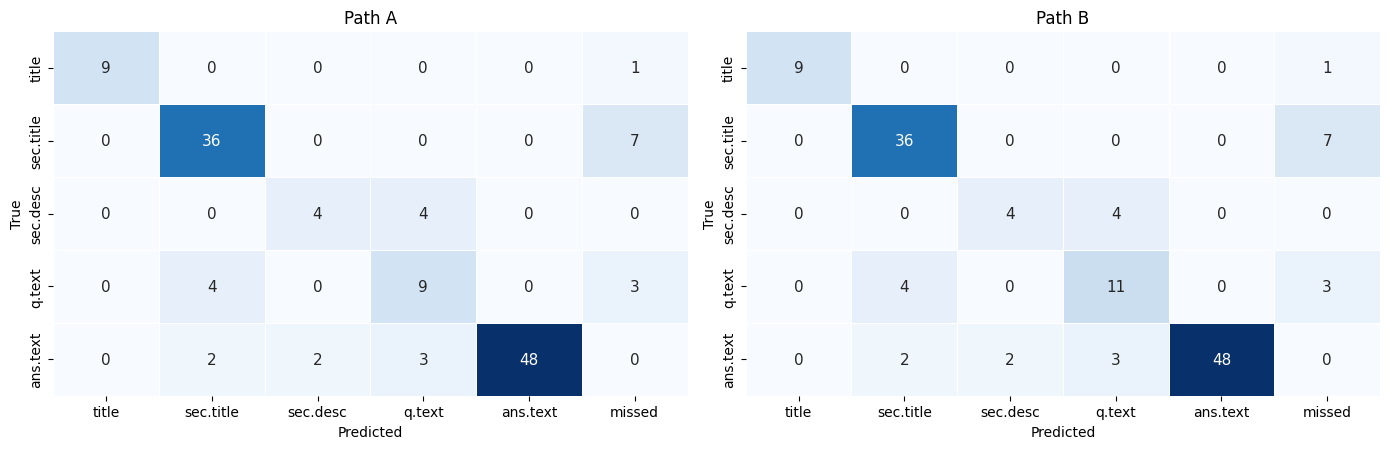

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, (path, conf) in zip(axes, (("A", conf_a), ("B", conf_b))):
    sns.heatmap(confusion_matrix_df(conf), annot=True, fmt="d", cmap="Blues",
                linewidths=0.5, linecolor="white", ax=ax, cbar=False,
                annot_kws={"size": 11})
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Path {path}")
plt.tight_layout()
plt.show()

## 5 — Where it goes wrong

The most common confusions, with example text.

In [7]:
print(f"Path B — {len(err_b)} error(s)\n")
counts = err_b.groupby(["true", "pred"]).size().sort_values(ascending=False)
print(f"{'true label':<24}{'predicted as':<24}{'count':>6}")
print('-' * 54)
for (t, p), c in counts.head(10).items():
    print(f"{t:<24}{p:<24}{c:>6}")
print("\n'no_gold_match' means the model produced an item with no counterpart in the reference.")

print("\nExamples:")
for _, e in err_b.head(8).iterrows():
    print(f"  [{e['sample']}]  {e['true']} -> {e['pred']}")
    print(f"      {e['text'][:100]!r}")

Path B — 42 error(s)

true label              predicted as             count
------------------------------------------------------
no_gold_match           answer.text                 12
no_gold_match           question.text                7
no_gold_match           section.title                6
question.text           section.title                4
section.description     question.text                4
answer.text             question.text                3
answer.text             section.description          2
answer.text             section.title                2
no_gold_match           section.description          1
no_gold_match           title                        1

'no_gold_match' means the model produced an item with no counterpart in the reference.

Examples:
  [sample1]  answer.text -> section.description
      'The following data will be created as a result of this project:'
  [sample1]  question.text -> section.title
      'Protections for privacy, rights, and confidentia

## 6 — What the annotation rules actually do

Path B applies `data/input/Rules.xlsx` to the structured output before scoring.
The table was rewritten on 6 August, so it is worth seeing which of its 16 rows
fire on real data and what each one changes.

In [8]:
import json
from collections import Counter
from dmpbridge.evaluation.annotation_rules import _RULES, _state, RULE_FIELDS
from dmpbridge.core import paths

ROWNO = {k: i + 1 for i, k in enumerate(_RULES)}
fired, effect = Counter(), Counter()

for n in range(1, 11):
    p = paths.structured_path(TAG, n)
    if not p.exists():
        continue
    t = json.loads(p.read_text(encoding='utf-8'))['narrative']['template']
    for s in t.get('section', []):
        for q in s.get('question', []):
            vals = {'title': t.get('title'),
                    'section.title': s.get('title'),
                    'section.description': s.get('description'),
                    'question.text': q.get('text')}
            key = tuple(_state(vals[f]) for f in RULE_FIELDS)
            fired[key] += 1
            action = _RULES[key]
            if action is None:
                effect['question already had text - left alone'] += 1
            else:
                effect[f'filled from {action[0]}'] += 1

print('Rows that fire on this run:')
print()
hdr = '/'.join(f.replace('section.', 'sec.').replace('question.text', 'q.text')
               for f in RULE_FIELDS)
print(f"{'row':>4}  {hdr:<40}{'action':<42}{'count':>6}")
print('-' * 94)
for k, v in _RULES.items():
    if not fired.get(k):
        continue
    act = 'leave unchanged' if v is None else f'{v[0]} -> {v[1]}'
    print(f"{ROWNO[k]:>4}  {'/'.join(k):<30}{act:<42}{fired[k]:>6}")

print()
print('What those actions do:')
print()
for k, v in effect.most_common():
    print(f'  {k:<44}{v:>4}')
print(f"  {'':<44}{'---':>4}")
print(f"  {'total questions':<44}{sum(effect.values()):>4}")

Rows that fire on this run:

 row  title/sec.title/sec.description/q.text  action                                     count
----------------------------------------------------------------------------------------------
   9  N/E/E/E                       title -> question.text                         3
  13  N/N/E/E                       section.title -> question.text                31
  14  N/N/E/N                       leave unchanged                               19
  15  N/N/N/E                       section.title -> question.text                 6
  16  N/N/N/N                       leave unchanged                                3

What those actions do:

  filled from section.title                     37
  question already had text - left alone        22
  filled from title                              3
                                               ---
  total questions                               62


### Path A vs Path B

The two paths now score almost identically (61.7% vs 61.6%). That is expected given
what the rules do here: of 78 questions, 45 are filled — 43 from `section.title` and 2
from the document title — and `extract_gold()` deliberately drops a `question.text` that
equals its section title, to avoid counting the same text twice. So most of what the
rules add is not counted as a separate item, and the two paths converge.

The visible difference is confined to `question.text`: 4.1% on Path A against 7.5% on
Path B. Both are poor, on 18 gold items.

> **On earlier figures in this notebook's history.** A run this morning showed Path B at
> 69.2% against Path A at 63.0%. That was produced by a misread of `Rules.xlsx` — the
> sheet's column order had changed, placing `question.text` in column 4 rather than
> column 2, and the rules were transcribed against the old order. The resulting table
> overwrote and cleared question text rather than filling it. Those numbers describe a
> rule set that was never intended and should be disregarded.

With the corrected column order the rules reproduce the new-version reference annotation
**exactly on all 10 documents**, including sample 5 — which had previously been treated
as needing an unimplemented sub-question merge. That merge turns out not to be required.

## Notes

- Repeated identical runs of this pipeline have varied by roughly **3 points of F1**, so
  differences smaller than that should not be read as real.
- Sample 5 will always show errors under Path B: its reference annotation merges several
  sub-questions into one with their answers joined, and no rule in `Rules.xlsx` covers merging.
- This is 1 of the 9 planned configurations (E01–E09). No other model or extractor has been
  run under the current pipeline.